# Setup

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import math
from itertools import combinations

from pathlib import Path
import csv
import json
import re
import os
from getpass import getpass
from datetime import datetime

import dimod
from dimod import cqm_to_bqm
from dwave.samplers import SimulatedAnnealingSampler
from dwave.system import LeapHybridBQMSampler
from dwave.system import LeapHybridCQMSampler

from rdkit import Chem
from rdkit.Chem import AllChem

## Settings

In [2]:
LOG_RUN = False

NUM_FRAGMENTS = 4
NUM_PAIRS = int(NUM_FRAGMENTS * (NUM_FRAGMENTS - 1) / 2)

Q_LINEAR = 0.95
Q_QUADRATIC = 0.95

SAMPLER = "SA"
LAMBDA_SINGLE = 1
LAMBDA_PAIR = 1
HARD_PENALTY = 10 * (LAMBDA_SINGLE * NUM_FRAGMENTS + LAMBDA_PAIR * NUM_PAIRS)

## Make Directories for Logging

In [3]:
if LOG_RUN:

    ### MAKE DIRECTORIES ###

    runs_dir = Path('./runs')
    runs_dir.mkdir(parents=True, exist_ok=True)

    existing = [p.name for p in runs_dir.iterdir() if p.is_dir() and p.name.startswith('run_')]
    nums = []
    for name in existing:
        suffix = name[4:]
        if suffix.isdigit():
            nums.append(int(suffix))

    next_num = (max(nums) + 1) if nums else 1
    new_run = runs_dir / f'run_{next_num:02d}'
    new_run.mkdir(exist_ok=False)

    RUN_FOLDER = new_run
    print(f'Created: {new_run}')

    DATA_FOLDER = RUN_FOLDER / "data"
    DATA_FOLDER.mkdir(parents=True, exist_ok=True)

    QUBO_FOLDER = RUN_FOLDER / "qubo"
    QUBO_FOLDER.mkdir(parents=True, exist_ok=True)

    RESULTS_FOLDER = RUN_FOLDER / "results"
    RESULTS_FOLDER.mkdir(parents=True, exist_ok=True)

# Load and Prepare Data

## Load CSV Files to Pandas
Note that `f12`, `f13`, and `f24` have energies calculated as **Non-Bonding + Bonding** due to need to reconnect fragments 1-2, 1-3, and 2-4 after docking. Other pairwise fragment energies are only **Non-Bonding**. 

In [4]:
NUM_FRAGMENTS = 4
NUM_PAIRS = math.comb(NUM_FRAGMENTS, 2)

# Load single-fragment dataframes
fragments = {
    i: pd.read_csv(f"data/raw/fragment_{i}_raw.csv")
    for i in range(1, NUM_FRAGMENTS + 1)
}

# Load pairwise dataframes
pairs = {
    (i, j): pd.read_csv(f"data/raw/pair_{i}_{j}_raw.csv")
    for i, j in combinations(range(1, NUM_FRAGMENTS + 1), 2)
}

## Shift Energies
We shift all energies by -E_min to set minimum energy at 0, and order others as >=0.

In [5]:
# Fragment energies
for i, df in fragments.items():
    df["energy_shifted"] = df["energy"] - df["energy"].min()

# Pair energies
for (i, j), df in pairs.items():
    df["energy_shifted"] = df["energy"] - df["energy"].min()

## Scale Linear Energies
For linear terms we perform **quantile scaling**. This means we scale them by dividing by Q-th quantile, and clip everything above 1 to 1.

In [6]:
for i, df in fragments.items():
    q = df["energy_shifted"].quantile(Q_LINEAR)
    df["score"] = (df["energy_shifted"] / q).clip(upper=1)

## Scale Pairwise Energies
For quadratic terms, due to long exponential tails, we first perform **logarithmic compression** `E -> log(1 + E)`, then perform **quantile scaling** with clipping.

In [7]:
for (i, j), df in pairs.items():
    
    # logarithmic compression
    df["log_energy"] = np.log1p(df["energy_shifted"])
    
    # quantile scaling with clipping
    q = df["log_energy"].quantile(Q_QUADRATIC)
    df["score"] = (df["log_energy"] / q).clip(upper=1)

## Export Processed Data

In [8]:
if LOG_RUN:

    # save fragments
    for i, df in fragments.items():
        df.to_csv(f"{RUN_FOLDER}/data/fragment_{i}_processed.csv", index=False)

    # save pairs
    for (i, j), df in pairs.items():
        df.to_csv(f"{RUN_FOLDER}/data/pair_{i}_{j}_processed.csv", index=False)

# QUBO

## Build the BQM

In [9]:
import dimod


def var_name(f: str, p: str) -> str:
    return f"x{{{f}, {p}}}"


def build_bqm(
    fragments: dict,
    pairs: dict,
    lambda_single: float = LAMBDA_SINGLE,
    lambda_pair: float = LAMBDA_PAIR,
    A: float = HARD_PENALTY,
    include_pairs=None,
) -> dimod.BinaryQuadraticModel:
    """
    Build a BQM for fragment docking using dict-based dataframes.

    Soft objective:
        Q_soft =
            lambda_single * sum(selected single-fragment scores)
          + lambda_pair   * sum(selected pairwise scores)

    Hard constraint:
        A * sum_f (sum_p x_{f,p} - 1)^2

    Notes
    -----
    - Scores are assumed to be in [0, 1].
    - For a feasible solution, the maximum soft contribution is approximately:
          lambda_single * NUM_FRAGMENTS + lambda_pair * NUM_ACTIVE_PAIRS
    """

    # ------------------------------------------------------------
    # 0) Validate / normalize inputs
    # ------------------------------------------------------------
    if include_pairs is None:
        include_pairs = sorted(pairs.keys())
    else:
        include_pairs = [tuple(pair) for pair in include_pairs]

    allowed_pairs = set(pairs.keys())
    if not set(include_pairs).issubset(allowed_pairs):
        raise ValueError(f"include_pairs must be a subset of available pairs: {allowed_pairs}")

    if len(include_pairs) == 0:
        raise ValueError("include_pairs cannot be empty")

    # local cleaned copies
    frag_dfs = {}
    for fid, df in fragments.items():
        df = df.copy()
        df["f"] = df["f"].astype(str)
        df["p"] = df["p"].astype(str)
        df["score"] = df["score"].astype(float)
        frag_dfs[str(fid)] = df

    pair_dfs = {}
    for pair_key, df in pairs.items():
        pair_key = tuple(pair_key)
        df = df.copy()
        df["f1"] = df["f1"].astype(str)
        df["f2"] = df["f2"].astype(str)
        df["p1"] = df["p1"].astype(str)
        df["p2"] = df["p2"].astype(str)
        df["score"] = df["score"].astype(float)
        pair_dfs[tuple(map(int, pair_key))] = df

    fragment_ids_str = [str(fid) for fid in sorted(fragments.keys())]

    # ------------------------------------------------------------
    # 1) Pose sets per fragment
    # ------------------------------------------------------------
    poses = {}
    for fid in fragment_ids_str:
        df = frag_dfs[fid]
        vals = df["p"].unique().tolist()
        poses[fid] = sorted(vals, key=lambda x: int(x) if str(x).isdigit() else str(x))

    # ------------------------------------------------------------
    # 2) Single score lookup
    # ------------------------------------------------------------
    s_single = {}
    for fid, df in frag_dfs.items():
        for _, r in df.iterrows():
            s_single[(fid, str(r["p"]))] = float(r["score"])

    # ------------------------------------------------------------
    # 3) Initialize BQM
    # ------------------------------------------------------------
    bqm = dimod.BinaryQuadraticModel({}, {}, 0.0, dimod.BINARY)

    # ------------------------------------------------------------
    # 4) Add variables + soft linear term
    # ------------------------------------------------------------
    for f in fragment_ids_str:
        for p in poses[f]:
            v = var_name(f, p)
            bqm.add_variable(v, 0.0)
            bqm.add_linear(v, lambda_single * s_single[(f, p)])

    # ------------------------------------------------------------
    # 5) Add soft quadratic term
    # ------------------------------------------------------------
    for pair_key in include_pairs:
        pair_key = tuple(pair_key)
        df = pair_dfs[pair_key]
        f1_key, f2_key = map(str, pair_key)

        for _, r in df.iterrows():
            p1 = str(r["p1"])
            p2 = str(r["p2"])
            score = float(r["score"])

            v1 = var_name(f1_key, p1)
            v2 = var_name(f2_key, p2)

            bqm.add_interaction(v1, v2, lambda_pair * score)

    # ------------------------------------------------------------
    # 6) Add hard one-hot penalty
    #    A * (sum_p x_fp - 1)^2
    # ------------------------------------------------------------
    for f in fragment_ids_str:
        frag_vars = [var_name(f, p) for p in poses[f]]

        # linear: -A * x_fp
        for v in frag_vars:
            bqm.add_linear(v, -A)

        # quadratic: +2A * x_fp x_fq
        for i in range(len(frag_vars)):
            for j in range(i + 1, len(frag_vars)):
                bqm.add_interaction(frag_vars[i], frag_vars[j], 2.0 * A)

        # constant: +A
        bqm.offset += A

    return bqm

## Initialize BQM

In [10]:
bqm = build_bqm(
    fragments=fragments,
    pairs=pairs,
    lambda_single=LAMBDA_SINGLE,
    lambda_pair=LAMBDA_PAIR,
    A=HARD_PENALTY,
)

print("BQM variables:", len(bqm.variables))
print("BQM interactions:", len(bqm.quadratic))
print("BQM offset:", bqm.offset)

BQM variables: 263
BQM interactions: 34453
BQM offset: 400.0


## Print QUBO Matrix

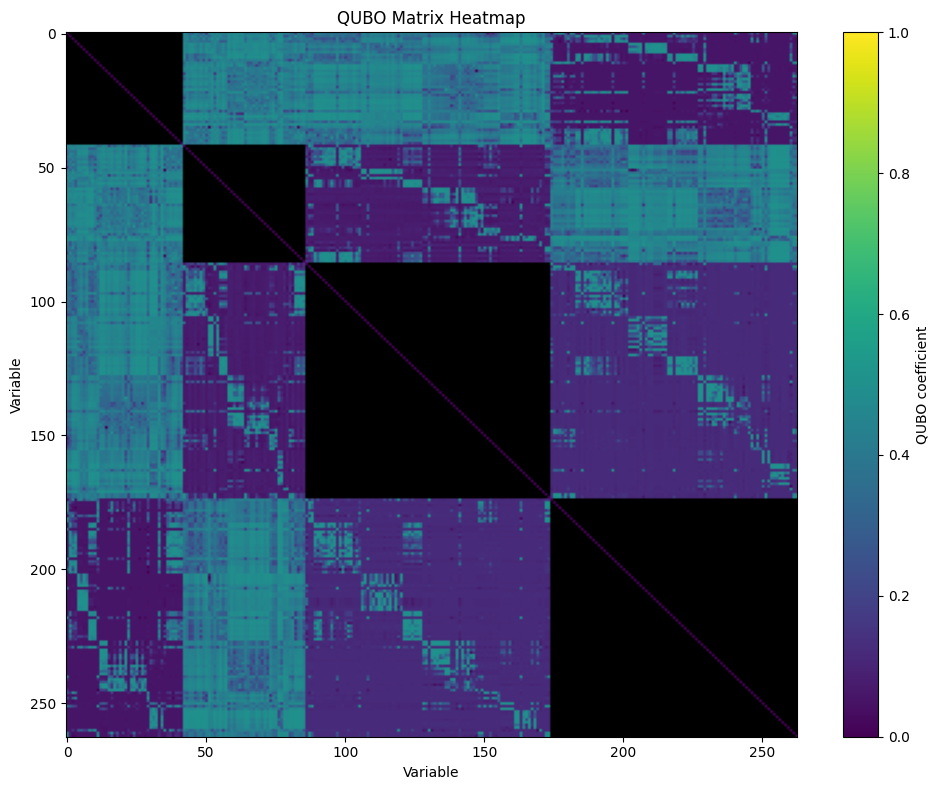

Soft-energy bound: 1
QUBO offset: 400.0
Matrix shape: (263, 263)


In [11]:
# Convert BQM → QUBO
Q, offset = bqm.to_qubo()

# Variable ordering
vars_order = sorted(bqm.variables)
var_to_idx = {v: i for i, v in enumerate(vars_order)}
n = len(vars_order)

# Export BQM model
if LOG_RUN and "QUBO_FOLDER" in globals():
    bqm_model_path = QUBO_FOLDER / "bqm_model.bqm"
    with bqm.to_file() as bqm_file:
        bqm_file.seek(0)
        with open(bqm_model_path, "wb") as fout:
            fout.write(bqm_file.read())
    print(f"Saved BQM model: {bqm_model_path}")

# Build symmetric QUBO matrix
Qmat = np.zeros((n, n), dtype=float)
for (u, v), bias in Q.items():
    i = var_to_idx[u]
    j = var_to_idx[v]
    if i == j:
        Qmat[i, j] += bias
    else:
        Qmat[i, j] += bias / 2
        Qmat[j, i] += bias / 2

# ---- plotting range for QUBO soft terms ----
Emax = max(LAMBDA_SINGLE, LAMBDA_PAIR)
Qmasked = np.ma.masked_where(Qmat > Emax, Qmat)

# Colormap with masked values in black
cmap = plt.cm.viridis.copy()
cmap.set_bad("black")

fig_qubo, ax_qubo = plt.subplots(figsize=(10, 8))
im_qubo = ax_qubo.imshow(Qmasked, cmap=cmap, vmin=0, vmax=Emax, aspect="auto")
fig_qubo.colorbar(im_qubo, ax=ax_qubo, label="QUBO coefficient")
ax_qubo.set_title("QUBO Matrix Heatmap")
ax_qubo.set_xlabel("Variable")
ax_qubo.set_ylabel("Variable")
fig_qubo.tight_layout()
if LOG_RUN and "QUBO_FOLDER" in globals():
    qubo_png = QUBO_FOLDER / "qubo_matrix.png"
    fig_qubo.savefig(qubo_png, dpi=200, bbox_inches="tight")
    print(f"Saved QUBO matrix plot: {qubo_png}")
plt.show()

print(f"Soft-energy bound: {Emax}")
print(f"QUBO offset: {offset}")
print(f"Matrix shape: {Qmat.shape}")

In [12]:
bqm.linear

{'x{1, 0}': -99.29657270940032, 'x{1, 1}': -99.18988467173394, 'x{1, 2}': -99.94872212274133, 'x{1, 3}': -99.92048485455615, 'x{1, 4}': -99.89356240373658, 'x{1, 5}': -99.89349979338584, 'x{1, 6}': -99.8866126548041, 'x{1, 7}': -99.87847330920748, 'x{1, 8}': -99.87390275360323, 'x{1, 9}': -99.87321403974505, 'x{1, 10}': -99.86670256326776, 'x{1, 11}': -99.82099700722523, 'x{1, 12}': -99.79620330833093, 'x{1, 13}': -100.0, 'x{1, 14}': -99.91109330194467, 'x{1, 15}': -99.88855357567714, 'x{1, 16}': -99.82938679422482, 'x{1, 17}': -99.14292690867654, 'x{1, 18}': -99.13109355238608, 'x{1, 19}': -99.0, 'x{1, 20}': -99.73277902302809, 'x{1, 21}': -99.72514056023742, 'x{1, 22}': -99.72319963936438, 'x{1, 23}': -99.69934509573123, 'x{1, 24}': -99.69652762994778, 'x{1, 25}': -99.69546325398515, 'x{1, 26}': -99.69458670907474, 'x{1, 27}': -99.68913960856008, 'x{1, 28}': -99.68782479119449, 'x{1, 29}': -99.687699570493, 'x{1, 30}': -99.6872612980378, 'x{1, 31}': -99.68244030103057, 'x{1, 32}': -9

In [13]:
# Soft vs hard coefficient diagnostics

linear = dict(bqm.linear)
quadratic = dict(bqm.quadratic)

lin_vals = np.array(list(linear.values()), dtype=float)
quad_vals = np.array(list(quadratic.values()), dtype=float)

print("Linear coefficients:")
print("  min   =", lin_vals.min())
print("  max   =", lin_vals.max())
print("  median=", np.median(lin_vals))

print("\nQuadratic coefficients:")
print("  min   =", quad_vals.min())
print("  max   =", quad_vals.max())
print("  median=", np.median(quad_vals))

# Separate likely hard vs soft by magnitude
soft_quad = quad_vals[np.abs(quad_vals) <= 1]
hard_quad = quad_vals[np.abs(quad_vals) > 1]

print("\nSoft quadratic coefficients (|J| <= 1):")
if len(soft_quad):
    print("  min   =", soft_quad.min())
    print("  max   =", soft_quad.max())
    print("  median=", np.median(soft_quad))

print("\nHard quadratic coefficients (|J| > 1):")
if len(hard_quad):
    print("  unique =", np.unique(hard_quad)[:10], "...")  # usually just 20

Linear coefficients:
  min   = -100.0
  max   = -99.0
  median= -99.63596098337813

Quadratic coefficients:
  min   = 0.0
  max   = 200.0
  median= 0.7894336004160774

Soft quadratic coefficients (|J| <= 1):
  min   = 0.0
  max   = 1.0
  median= 0.2653460183359806

Hard quadratic coefficients (|J| > 1):
  unique = [200.] ...


## Sample with D-Wave Simulated Annealing (BQM)

In [14]:
import time

if SAMPLER == "SA":
    sampler = SimulatedAnnealingSampler()

    NUM_VARIABLES = bqm.num_variables
    NUM_INTERACTIONS = bqm.num_interactions

    NUM_READS = 2000
    NUM_SWEEPS = 1000

    t0 = time.perf_counter()
    sampleset = sampler.sample(bqm, num_reads=NUM_READS, num_sweeps=NUM_SWEEPS)
    SOLVING_TIME = time.perf_counter() - t0
    sampleset = sampleset.aggregate()
    print(f"Solving time ({SAMPLER}): {SOLVING_TIME:.3f} s")
    sampleset

elif SAMPLER == "BQM":
    token = os.getenv("DWAVE_API_TOKEN") or getpass("Enter D-Wave API token: ")
    sampler = LeapHybridBQMSampler(token=token)

    NUM_VARIABLES = bqm.num_variables
    NUM_INTERACTIONS = bqm.num_interactions

    t0 = time.perf_counter()
    sampleset = sampler.sample(bqm)
    SOLVING_TIME = time.perf_counter() - t0
    sampleset = sampleset.aggregate()
    print(f"Solving time ({SAMPLER}): {SOLVING_TIME:.3f} s")
    sampleset

else:
    raise NameError(f"SAMPLER name {SAMPLER} is not valid. Please use SA or BQM")
    

Solving time (SA): 8.137 s


In [15]:
if LOG_RUN:

    metadata = {
        "run_number": RUN_FOLDER.name,
        "datetime": datetime.now().isoformat(),

        "problem_parameters": {
            "NUM_FRAGMENTS": NUM_FRAGMENTS,
            "NUM_PAIRS": NUM_PAIRS,
            "Q_LINEAR": Q_LINEAR,
            "Q_QUADRATIC": Q_QUADRATIC
        },

        "qubo_parameters": {
            "HARD_PENALTY": HARD_PENALTY,
            "LAMBDA_SINGLE": LAMBDA_SINGLE,
            "LAMBDA_PAIR": LAMBDA_PAIR
        },

        "solver_parameters": {
            "SAMPLER": SAMPLER,
            "NUM_VARIABLES": NUM_VARIABLES if "NUM_VARIABLES" in globals() else bqm.num_variables,
            "NUM_INTERACTIONS": NUM_INTERACTIONS if "NUM_INTERACTIONS" in globals() else bqm.num_interactions,
            "SOLVING_TIME": SOLVING_TIME if "SOLVING_TIME" in globals() else None
        }
    }

    json_path = RUN_FOLDER / "run_metadata.json"

    with open(json_path, "w", encoding="utf-8") as f:
        json.dump(metadata, f, indent=4)

    print("Saved run metadata:", json_path)

## Print chosen poses per sample

In [16]:
# Pretty-print chosen poses per sample with score and raw energy

fragment_ids = [str(fid) for fid in sorted(fragments.keys())]


def chosen_poses(sample: dict) -> dict:
    """
    Returns {fragment: pose} when exactly one pose is selected per fragment.
    Returns None for fragments with zero or multiple selected poses.
    """
    out = {f: [] for f in fragment_ids}
    for k, v in sample.items():
        if not v:
            continue
        if not (k.startswith("x{") and k.endswith("}")):
            continue
        inside = k[2:-1]  # e.g. "1, 8"
        f, p = [s.strip() for s in inside.split(",")]
        if f in out:
            out[f].append(p)

    return {f: (vals[0] if len(vals) == 1 else None) for f, vals in out.items()}


SINGLE_INDEX = {}
for fid, df in fragments.items():
    c = df.copy()
    c["p"] = c["p"].astype(str)
    SINGLE_INDEX[str(fid)] = c.set_index("p")

PAIR_INDEX = {}
for (fa, fb), df in pairs.items():
    c = df.copy()
    c["p1"] = c["p1"].astype(str)
    c["p2"] = c["p2"].astype(str)
    PAIR_INDEX[f"{fa}{fb}"] = (str(fa), str(fb), c.set_index(["p1", "p2"]))

requested_pairs = tuple(globals().get("ACTIVE_PAIRS", tuple(PAIR_INDEX.keys())))
active_pairs = tuple(code for code in requested_pairs if code in PAIR_INDEX)
if not active_pairs:
    raise ValueError("No valid active pair codes found in ACTIVE_PAIRS")


def evaluate_solution(sel: dict, pair_codes) -> dict:
    single_score = 0.0
    single_raw = 0.0

    for f in fragment_ids:
        p = sel[f]
        row = SINGLE_INDEX[f].loc[p]
        single_score += float(row["score"])
        single_raw += float(row["energy"])

    pair_score = 0.0
    pair_raw = 0.0

    for code in pair_codes:
        fa, fb, idx = PAIR_INDEX[code]
        row = idx.loc[(sel[fa], sel[fb])]
        pair_score += float(row["score"])
        pair_raw += float(row["energy"])

    return {
        "score_single": single_score,
        "score_pair": pair_score,
        "score_total": single_score + pair_score,
        "raw_single": single_raw,
        "raw_pair": pair_raw,
        "raw_total": single_raw + pair_raw,
    }


# Prefer feasible samples if provided; otherwise use full sampleset
if "feasible" in globals():
    source_samples = feasible
elif "sampleset" in globals():
    source_samples = sampleset
else:
    raise NameError("Neither 'feasible' nor 'sampleset' is defined")

# Print first N valid one-hot solutions in a compact list format
N = 20
rows = []
for rec in source_samples.data(["sample", "energy"]):
    sel = chosen_poses(rec.sample)
    if any(sel[f] is None for f in fragment_ids):
        continue

    xs = [f"x{{{f}, {sel[f]}}}" for f in fragment_ids]
    metrics = evaluate_solution(sel, active_pairs)
    rows.append({
        "solution": xs,
        "bqm_energy": float(rec.energy),
        **metrics,
    })

    if len(rows) >= N:
        break

for i, row in enumerate(rows, start=1):
    print(
        f"{i:02d}. {row['solution']} | "
        f"score={row['score_total']:.2f} | "
        f"raw_energy={row['raw_total']:.2f}"
    )

if rows:
    SCORE = f"{rows[0]['score_total']:.2f}"
else:
    SCORE = "NA"
    print("No valid one-hot solutions found in the sample set.")

if LOG_RUN and rows:
    csv_path = RESULTS_FOLDER / f'{SAMPLER}_lam-{LAMBDA_PAIR}-{LAMBDA_SINGLE}_solutions.csv'
    with open(csv_path, "w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow(["rank", "solution", "score", "raw_energy"])
        for i, row in enumerate(rows, start=1):
            solution = row["solution"]
            score = row["score_total"]
            energy = row["raw_total"]
            writer.writerow([i, solution, f"{score:.2f}", f"{energy:.2f}"])
    print(f"Wrote CSV to {csv_path}")
elif LOG_RUN:
    print("Skipped CSV export because no valid one-hot rows were found.")


01. ['x{1, 9}', 'x{2, 18}', 'x{3, 43}', 'x{4, 47}'] | score=2.67 | raw_energy=1949127.15
02. ['x{1, 2}', 'x{2, 19}', 'x{3, 5}', 'x{4, 36}'] | score=3.40 | raw_energy=7227179.04
03. ['x{1, 6}', 'x{2, 34}', 'x{3, 13}', 'x{4, 44}'] | score=3.41 | raw_energy=9865001.89
04. ['x{1, 6}', 'x{2, 20}', 'x{3, 42}', 'x{4, 64}'] | score=3.48 | raw_energy=10067107.46
05. ['x{1, 13}', 'x{2, 16}', 'x{3, 33}', 'x{4, 55}'] | score=3.52 | raw_energy=2093436.61
06. ['x{1, 15}', 'x{2, 6}', 'x{3, 38}', 'x{4, 24}'] | score=3.52 | raw_energy=11078586.20
07. ['x{1, 3}', 'x{2, 2}', 'x{3, 21}', 'x{4, 58}'] | score=3.53 | raw_energy=1340031.61
08. ['x{1, 2}', 'x{2, 13}', 'x{3, 29}', 'x{4, 45}'] | score=3.54 | raw_energy=2746087.03
09. ['x{1, 3}', 'x{2, 0}', 'x{3, 15}', 'x{4, 38}'] | score=3.56 | raw_energy=8629119.56
10. ['x{1, 16}', 'x{2, 11}', 'x{3, 50}', 'x{4, 18}'] | score=3.56 | raw_energy=13299206.89
11. ['x{1, 15}', 'x{2, 2}', 'x{3, 30}', 'x{4, 1}'] | score=3.56 | raw_energy=10629736.50
12. ['x{1, 37}', 'x

# Drawing Molecules

In [17]:
def extract_poses(index, rows):
    sol = rows[index]["solution"]
    i1, i2, i3, i4 = [int(re.findall(r'\d+', s)[1]) for s in sol]
    return i1, i2, i3, i4

In [18]:
with Chem.SDMolSupplier('./data/spdf/fragment_1.sdf') as s1:
	with Chem.SDMolSupplier('./data/spdf/fragment_2.sdf') as s2:
		with Chem.SDMolSupplier('./data/spdf/fragment_3.sdf') as s3:
			with Chem.SDMolSupplier('./data/spdf/fragment_4.sdf') as s4:
				i1, i2, i3, i4 = extract_poses(0, rows)
				mol1, mol2, mol3, mol4 = s1[i1], s2[i2], s3[i3], s4[i4]
				
				combined = Chem.CombineMols(mol1, mol2)
				combined = Chem.CombineMols(combined, mol3)
				combined = Chem.CombineMols(combined, mol4)
				
				combined_mol = Chem.AddHs(combined, explicitOnly = True)
				combined_mol = Chem.RemoveHs(combined)
				editable_mol = Chem.EditableMol(combined)
				
				# 1 - 2
				editable_mol.AddBond(12, 21, order = Chem.BondType.SINGLE)
				# 1 - 3
				editable_mol.AddBond(9, 22, order = Chem.BondType.SINGLE)
				# 2 - 4
				editable_mol.AddBond(17, 26, order = Chem.BondType.SINGLE)
				
				combined = editable_mol.GetMol()
				
				combined.GetAtomWithIdx(12).SetNumExplicitHs(0)
				combined.GetAtomWithIdx(9).SetNumExplicitHs(0)
				combined.GetAtomWithIdx(17).SetNumExplicitHs(0)
				
				Chem.SanitizeMol(combined)

				if LOG_RUN:
					writer = Chem.SDWriter(RESULTS_FOLDER / f'{SAMPLER}_lam-{LAMBDA_PAIR}-{LAMBDA_SINGLE}_score-{SCORE}.sdf')
					writer.write(combined)
					writer.close()
				else:
					
					TEST_DIR = Path(f'test_{SAMPLER}_nr-{NUM_READS}_ns-{NUM_SWEEPS}')
					TEST_DIR.mkdir(parents=True, exist_ok=True)
					writer = Chem.SDWriter(TEST_DIR / f'{SAMPLER}_lam-{LAMBDA_PAIR}-{LAMBDA_SINGLE}_score-{SCORE}.sdf')
					writer.write(combined)
					writer.close()
